In [50]:
import sys
sys.path.append(r"C:\dev\LEAP\build\lib")

import os
import numpy as np
import pydicom
from pydicom.uid import ExplicitVRLittleEndian
import tifffile
from scipy.ndimage import gaussian_filter
from leapctype import *

import matplotlib.pyplot as plt

In [51]:
leapct = tomographicModels()

def load_raw_projection_dicom(dcm_path):
    ds = pydicom.dcmread(dcm_path)
    raw_proj = ds.pixel_array.astype(np.float32)
    return ds, raw_proj
    
def extract_cbct_geometry_from_dcm(ds, raw_proj):
    num_views, det_rows, det_cols = raw_proj.shape

    val = getattr(ds, "ImagerPixelSpacing", None)
    if val is None:
        val = getattr(ds, "PixelSpacing", None)

    if isinstance(val, (list, tuple)):
        pixel_height, pixel_width = map(float, val)
    elif val is not None:
        pixel_height = pixel_width = float(val)
    else:
        pixel_height = pixel_width = 1.0

    center_row = 0.5 * (det_rows - 1)
    center_col = 0.5 * (det_cols - 1)

    sod = float(getattr(ds, "DistanceSourceToPatient", 462.817))
    sdd = float(getattr(ds, "DistanceSourceToDetector", 724.296))

    angles_deg = np.linspace(0, 360, num_views, endpoint=False).astype(np.float32)

    return {
        "num_views": num_views,
        "det_rows": det_rows,
        "det_cols": det_cols,
        "pixel_height": pixel_height,
        "pixel_width": pixel_width,
        "center_row": center_row,
        "center_col": center_col,
        "angles_deg": angles_deg,
        "sod": sod,
        "sdd": sdd,
    }
def extract_cbct_geometry_from_dcm(ds, raw_proj):
    num_views, det_rows, det_cols = raw_proj.shape

    val = getattr(ds, "ImagerPixelSpacing", None)
    if val is None:
        val = getattr(ds, "PixelSpacing", None)

    if isinstance(val, (list, tuple)):
        pixel_height, pixel_width = map(float, val)
    elif val is not None:
        pixel_height = pixel_width = float(val)
    else:
        pixel_height = pixel_width = 1.0

    center_row = 0.5 * (det_rows - 1)
    center_col = 0.5 * (det_cols - 1)

    sod = float(getattr(ds, "DistanceSourceToPatient", 462.817))
    sdd = float(getattr(ds, "DistanceSourceToDetector", 724.296))

    angles_deg = np.linspace(0, 360, num_views, endpoint=False).astype(np.float32)

    return {
        "num_views": num_views,
        "det_rows": det_rows,
        "det_cols": det_cols,
        "pixel_height": pixel_height,
        "pixel_width": pixel_width,
        "center_row": center_row,
        "center_col": center_col,
        "angles_deg": angles_deg,
        "sod": sod,
        "sdd": sdd,
    }

def extract_cbct_geometry_from_dcm(ds, raw_proj):
    num_views, det_rows, det_cols = raw_proj.shape

    val = getattr(ds, "ImagerPixelSpacing", None)
    if val is None:
        val = getattr(ds, "PixelSpacing", None)

    if isinstance(val, (list, tuple)):
        pixel_height, pixel_width = map(float, val)
    elif val is not None:
        pixel_height = pixel_width = float(val)
    else:
        pixel_height = pixel_width = 1.0

    center_row = 0.5 * (det_rows - 1)
    center_col = 0.5 * (det_cols - 1)

    sod = float(getattr(ds, "DistanceSourceToPatient", 462.817))
    sdd = float(getattr(ds, "DistanceSourceToDetector", 724.296))

    angles_deg = np.linspace(0, 360, num_views, endpoint=False).astype(np.float32)

    return {
        "num_views": num_views,
        "det_rows": det_rows,
        "det_cols": det_cols,
        "pixel_height": pixel_height,
        "pixel_width": pixel_width,
        "center_row": center_row,
        "center_col": center_col,
        "angles_deg": angles_deg,
        "sod": sod,
        "sdd": sdd,
    }

def setup_conebeam(geom):
    # PanelUOffset = 0.392
    # PanelVOffset = 37.746
    # PanelUOffset = 0

    PanelUOffset = 0
    PanelVOffset = 0


    print('geom["pixel_width]: ', geom["pixel_width"])
    u_offset_pix = PanelUOffset / geom["pixel_width"]
    v_offset_pix = PanelVOffset / geom["pixel_height"]

    # center_col = 0.5 * (geom["det_cols"] - 1) + u_offset_pix
    # center_row = 0.5 * (geom["det_rows"] - 1) + v_offset_pix

    leapct.set_conebeam(
        numAngles=geom["num_views"],
        numRows=geom["det_rows"],
        numCols=geom["det_cols"],
        pixelHeight=geom["pixel_height"],
        pixelWidth=geom["pixel_width"],
        # centerRow=geom["center_row"],
        # centerCol=geom["center_col"],
        # centerRow= 0.5 * (geom["det_cols"] - 1) + u_offset_pix,
        # centerCol = 0.5 * (geom["det_rows"] - 1) + v_offset_pix,
        centerRow = geom["center_row"] + u_offset_pix,
        centerCol = geom["center_col"] + v_offset_pix,
        phis=geom["angles_deg"].astype(np.float32),
        # phis=np.mod(geom["angles_deg"] - 90.0, 360.0).astype(np.float32),
        sod=geom["sod"],
        sdd=geom["sdd"],
    )

def setup_volume_from_mask(metal_vol, voxel_size_mm=0.5):
    nz, ny, nx = metal_vol.shape

    # Adjust this call to your LEAP volume API if the signature differs.
    leapct.set_volume(
        numX=nx,
        numY=ny,
        numZ=nz,
        voxelWidth=voxel_size_mm,
        voxelHeight=voxel_size_mm
    )

def allocate_and_project(volume):
    g = leapct.allocate_projections()
    f = leapct.allocate_volume()

    print("Input volume shape:", volume.shape)
    print("LEAP volume shape:", None if f is None else f.shape)

    if f.shape != volume.shape:
        raise ValueError(f"Volume shape mismatch: LEAP {f.shape} vs input {volume.shape}")

    f[:] = volume.astype(np.float32)
    leapct.project(g, f)
    return g.copy()

def reconstruct_fdk(proj):
    g = leapct.allocate_projections()
    f = leapct.allocate_volume()

    if g.shape != proj.shape:
        raise ValueError(f"Projection shape mismatch: LEAP {g.shape} vs proj {proj.shape}")

    g[:] = proj.astype(np.float32)
    f[:] = 0
    leapct.FBP(g, f)
    return f.copy()

def interp_1d_over_mask(signal_1d, mask_1d):
    out = signal_1d.copy()
    metal_idx = np.where(mask_1d)[0]
    nonmetal_idx = np.where(~mask_1d)[0]

    if len(metal_idx) == 0:
        return out
    if len(nonmetal_idx) < 2:
        return out

    out[metal_idx] = np.interp(metal_idx, nonmetal_idx, signal_1d[nonmetal_idx])
    return out

def interp_proj_stack(proj, metal_trace):
    out = proj.copy()
    num_views, det_rows, _ = proj.shape

    for v in range(num_views):
        for r in range(det_rows):
            out[v, r] = interp_1d_over_mask(proj[v, r], metal_trace[v, r])

    return out

def hu_to_mu(vol_hu, mu_water=0.19):
    return mu_water * (1.0 + vol_hu / 1000.0)


def mu_to_hu(vol_mu, mu_water=0.19):
    return (vol_mu / mu_water - 1.0) * 1000.0

# def build_prior_from_li(vol_li_mu, metal_vol, mu_air=0.0, mu_water=0.19, bone_thresh=0.25):
#     prior = gaussian_filter(vol_li_mu, sigma=1.0)

# def build_prior_from_li(vol_li_mu, metal_vol, mu_air=0.0, mu_water=0.008, bone_thresh=0.015):
#     prior = gaussian_filter(vol_li_mu, sigma=1.0)

#     prior[prior < mu_air] = mu_air

#     # remove metal from prior
#     prior[metal_vol > 0] = mu_water

#     # simple 3-class style prior
#     air_mask = prior <= 0.02
#     soft_mask = (prior > 0.02) & (prior < bone_thresh)

#     prior[air_mask] = mu_air
#     prior[soft_mask] = mu_water
#     # bone is left as-is

#     return prior

# def build_prior_from_li(vol_li_mu, metal_vol,
#                         mu_air=0.0,
#                         mu_water=0.008,
#                         air_thresh=0.0005,
#                         bone_thresh=0.01):

#     prior = gaussian_filter(vol_li_mu, sigma=1.0)

#     # clamp negatives
#     prior[prior < 0] = 0

#     # remove metal
#     prior[metal_vol > 0] = mu_water

#     # segmentation
#     air_mask = prior <= air_thresh
#     soft_mask = (prior > air_thresh) & (prior < bone_thresh)

#     prior[air_mask] = mu_air
#     prior[soft_mask] = mu_water
#     # bone stays as-is

#     return prior

def build_prior_from_li(vol_li_mu, metal_vol,
                        mu_air=0.0,
                        mu_water=0.015,
                        air_thresh=0.0025,
                        bone_thresh=0.02):
    prior = gaussian_filter(vol_li_mu, sigma=1.0)
    
    prior[prior < 0] = 0
    
    # remove metal from prior
    prior[metal_vol > 0] = mu_water
    
    air_mask = prior <= air_thresh
    soft_mask = (prior > air_thresh) & (prior < bone_thresh)
    
    prior[air_mask] = mu_air
    prior[soft_mask] = mu_water
    # prior[soft_mask] = 0.7 * prior[soft_mask] + 0.3 * mu_water
    # bone stays as-is
    
    return prior





In [52]:
def save_projection_stack_as_dcm(template_ds, proj_stack, out_path):
    """
    Save projection stack (views, rows, cols) into a DICOM file
    using a template dataset.
    """

    ds = template_ds.copy()

    # ---- ensure dtype ----
    if proj_stack.dtype != np.uint16:
        # normalize to 16-bit range
        proj_min = proj_stack.min()
        proj_max = proj_stack.max()

        proj_scaled = (proj_stack - proj_min) / (proj_max - proj_min + 1e-6)
        proj_scaled = (proj_scaled * 65535).astype(np.uint16)
    else:
        proj_scaled = proj_stack

    # ---- update dimensions ----
    num_views, rows, cols = proj_scaled.shape

    ds.NumberOfFrames = str(num_views)
    ds.Rows = rows
    ds.Columns = cols

    # ---- flatten pixel data ----
    ds.PixelData = proj_scaled.tobytes()

    # ---- critical: make it uncompressed ----
    ds.file_meta.TransferSyntaxUID = ExplicitVRLittleEndian
    ds.is_little_endian = True
    ds.is_implicit_VR = False

    # ---- required fields ----
    ds.BitsAllocated = 16
    ds.BitsStored = 16
    ds.HighBit = 15
    ds.PixelRepresentation = 0  # unsigned

    # ---- save ----
    ds.save_as(out_path)

    print(f"Saved DICOM: {out_path}")

In [53]:
    raw_dcm_path = r"D:\NMAR\case_01_MFOV\pyrecon\raw\case_13_40006_CEUE00388452_wrist_R_UC.dcm"
    metal_mask_path = r"D:\NMAR\case_01_MFOV\mar_metal_mask_vol.tif"
    out_dir = r"D:\NMAR\cbct_nmar_nb"
    os.makedirs(out_dir, exist_ok=True)

In [54]:
# 1) Load raw projections
ds, raw_proj = load_raw_projection_dicom(raw_dcm_path)
print("raw_proj shape:", raw_proj.shape)

#need to setup a vol to run fdk
metal_vol = tifffile.imread(metal_mask_path)
metal_vol = (metal_vol > 0).astype(np.float32)
print("metal_vol shape:", metal_vol.shape)
setup_volume_from_mask(metal_vol, voxel_size_mm=0.5)

I = raw_proj.astype(np.float32)
I0 = np.percentile(I, 99.9)
proj_log = -np.log(np.clip(I / I0, 1e-6, None))

raw_proj shape: (480, 768, 1024)
metal_vol shape: (380, 510, 510)


geom["pixel_width]:  0.388


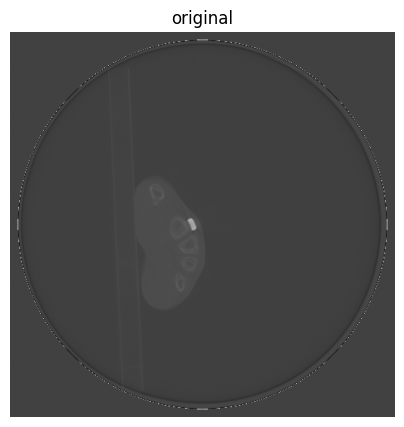

geom["pixel_width]:  0.388


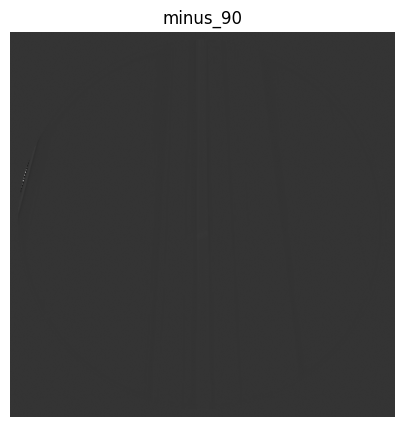

geom["pixel_width]:  0.388


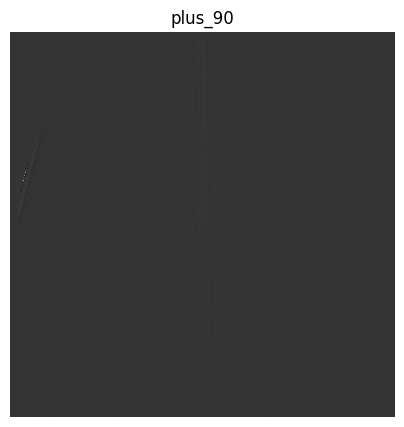

geom["pixel_width]:  0.388


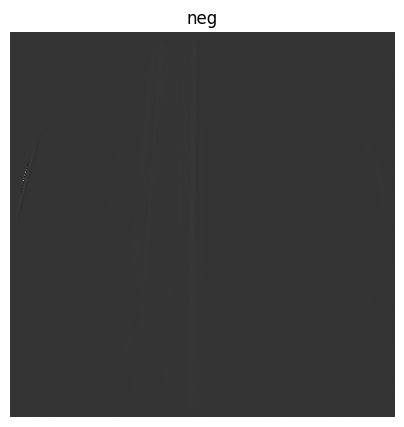

geom["pixel_width]:  0.388


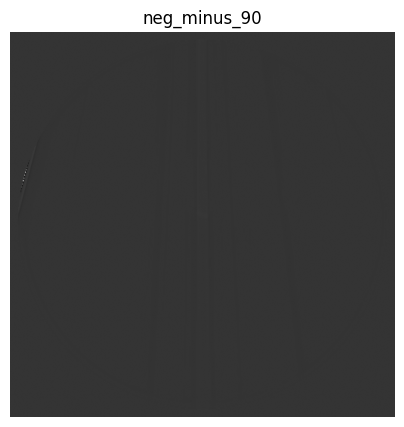

geom["pixel_width]:  0.388


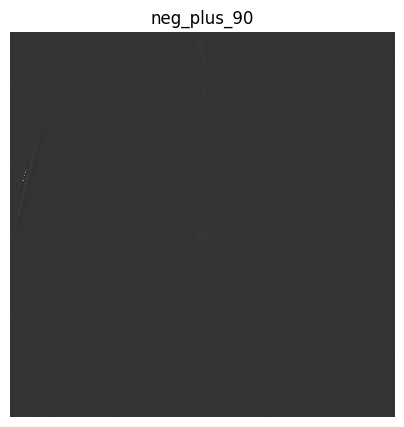

In [55]:
geom = extract_cbct_geometry_from_dcm(ds, raw_proj)

tests = {
    "original": geom["angles_deg"].copy(),
    "minus_90": np.mod(geom["angles_deg"] - 90.0, 360.0).astype(np.float32),
    "plus_90": np.mod(geom["angles_deg"] + 90.0, 360.0).astype(np.float32),
    "neg": np.mod(-geom["angles_deg"], 360.0).astype(np.float32),
    "neg_minus_90": np.mod(-(geom["angles_deg"] - 90.0), 360.0).astype(np.float32),
    "neg_plus_90": np.mod(-(geom["angles_deg"] + 90.0), 360.0).astype(np.float32),
}

import matplotlib.pyplot as plt

base_geom = extract_cbct_geometry_from_dcm(ds, raw_proj)

for name, ang in tests.items():
    geom = dict(base_geom)
    geom["angles_deg"] = ang
    setup_conebeam(geom)

    vol = reconstruct_fdk(proj_log)
    z = vol.shape[0] // 2

    plt.figure(figsize=(5, 5))
    plt.imshow(vol[z], cmap="gray")
    plt.title(name)
    plt.axis("off")
    plt.show()

geom["pixel_width]:  0.388


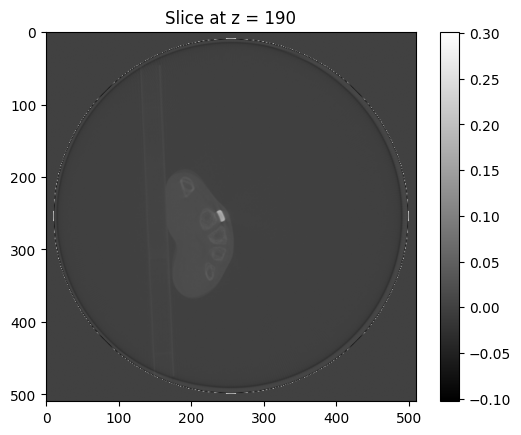

In [56]:
#2) Geometry from DICOM

geom = extract_cbct_geometry_from_dcm(ds, raw_proj)
# geom["angles_deg"] = np.mod(geom["angles_deg"] + 90.0, 360.0).astype(np.float32)
setup_conebeam(geom)


vol_test = reconstruct_fdk(proj_log)
z = vol_test.shape[0] // 2
slice_2d = vol_test[z]

plt.imshow(slice_2d, cmap='gray')
plt.colorbar()
plt.title(f"Slice at z = {z}")
plt.show()



metal_vol shape: (380, 510, 510)
geom["pixel_width]:  0.388
Input volume shape: (380, 510, 510)
LEAP volume shape: (380, 510, 510)


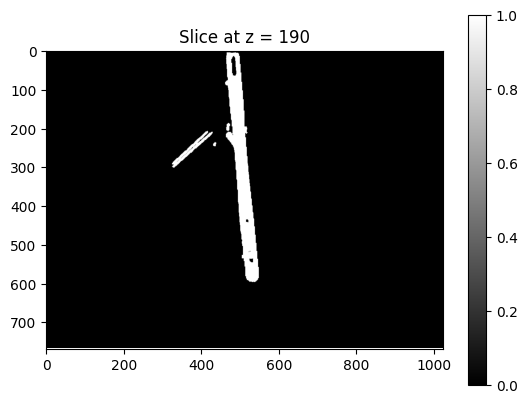

In [57]:
# 3) Load metal mask

metal_vol = tifffile.imread(metal_mask_path)
metal_vol = (metal_vol > 0).astype(np.float32)
print("metal_vol shape:", metal_vol.shape)
setup_volume_from_mask(metal_vol, voxel_size_mm=0.5)

# # # 4) Configure LEAP
setup_conebeam(geom)
setup_volume_from_mask(metal_vol, voxel_size_mm=0.5)



# # # 5) Forward project metal mask
metal_proj = allocate_and_project(metal_vol)
# metal_trace = metal_proj > 1e-6
# #
metal_trace = metal_proj > (0.02 * metal_proj.max())
np.save(os.path.join(out_dir, "metal_proj.npy"), metal_proj)
np.save(os.path.join(out_dir, "metal_trace.npy"), metal_trace.astype(np.uint8))

# pick a representative view (middle angle)
v = metal_trace.shape[0] // 2

out_path = os.path.join(out_dir, "metal_trace_mid_view.tif")

# # scale for visibility (0 → 0, 1 → 255)
# tifffile.imwrite(out_path, (slice_2d * 255).astype(np.uint8))

# print(f"Saved: {out_path}")
          
slice_2d = metal_trace[v].astype(np.uint8)  # 0/1 mask

plt.imshow(slice_2d, cmap='gray')
plt.colorbar()
plt.title(f"Slice at z = {z}")
plt.show()



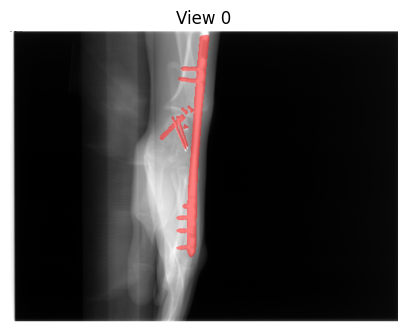

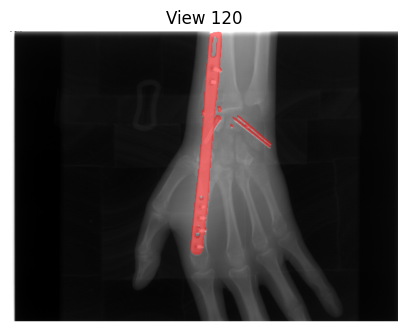

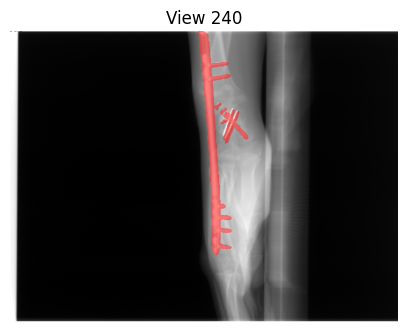

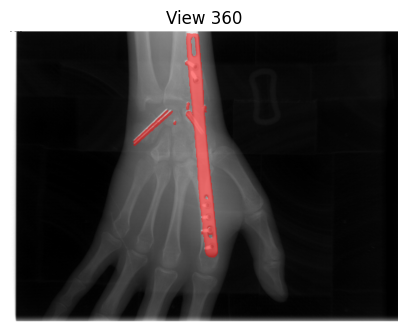

In [58]:
N = proj_log.shape[0]
shift = N // 4

metal_trace_corr = np.empty_like(metal_trace)
for v in range(N):
    metal_trace_corr[v] = metal_trace[(v - shift) % N]

for v in [0, 120, 240, 360]:
        raw = proj_log[v] if 'proj_log' in locals() else raw_proj[v]
        mask = metal_trace_corr[v]
        # mask = mask_trace[v]
        # mask = metal_trace_fixed[v]
        # mask = metal_trace[(v - shift) % proj_log.shape[0]]

        p1, p99 = np.percentile(raw, (1, 99))
        raw_norm = np.clip((raw - p1) / (p99 - p1 + 1e-6), 0, 1)

        rgb = np.stack([raw_norm, raw_norm, raw_norm], axis=-1)

        alpha = 0.5
        rgb[..., 0] = np.where(mask, (1 - alpha) * rgb[..., 0] + alpha * 1.0, rgb[..., 0])
        rgb[..., 1] = np.where(mask, (1 - alpha) * rgb[..., 1], rgb[..., 1])
        rgb[..., 2] = np.where(mask, (1 - alpha) * rgb[..., 2], rgb[..., 2])

        out_path = os.path.join(out_dir, f"metal_trace02_overlay_{v:04d}.tif")
        tifffile.imwrite(out_path, (rgb * 255).astype(np.uint8))

           # 👇 Show instead of save
        plt.figure(figsize=(5, 5))
        plt.imshow(rgb)
        plt.title(f"View {v}")
        plt.axis("off")
        plt.show()


## hide test

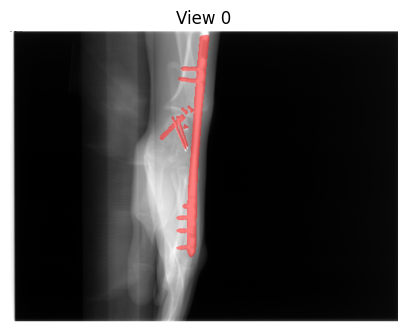

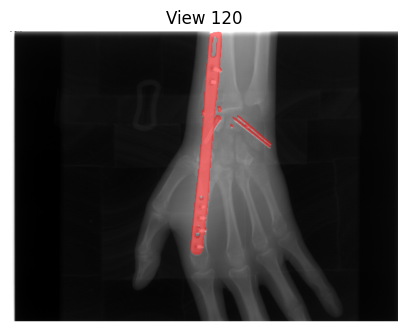

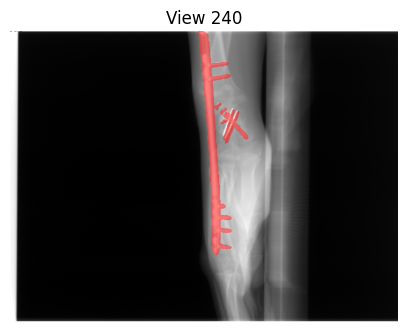

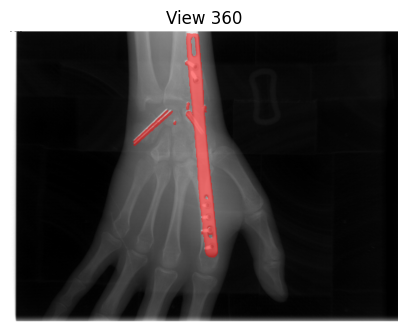

In [46]:
shift = proj_log.shape[0] // 4
# mask_trace = metal_trace[(v - shift) % proj_log.shape[0]]
# metal_trace = np.roll(metal_trace, shift=-shift, axis=0)

# shift = proj_log.shape[0] // 4
# metal_trace_fixed = np.roll(metal_trace, shift=shift, axis=0)
# metal_trace_fixed = np.flip(metal_trace_fixed, axis=2)   # horizontal flip

for v in [0, 120, 240, 360]:
        raw = proj_log[v] if 'proj_log' in locals() else raw_proj[v]
        # mask = metal_trace[v]
        # mask = mask_trace[v]
        # mask = metal_trace_fixed[v]
        mask = metal_trace[(v - shift) % proj_log.shape[0]]

        p1, p99 = np.percentile(raw, (1, 99))
        raw_norm = np.clip((raw - p1) / (p99 - p1 + 1e-6), 0, 1)

        rgb = np.stack([raw_norm, raw_norm, raw_norm], axis=-1)

        alpha = 0.5
        rgb[..., 0] = np.where(mask, (1 - alpha) * rgb[..., 0] + alpha * 1.0, rgb[..., 0])
        rgb[..., 1] = np.where(mask, (1 - alpha) * rgb[..., 1], rgb[..., 1])
        rgb[..., 2] = np.where(mask, (1 - alpha) * rgb[..., 2], rgb[..., 2])

        out_path = os.path.join(out_dir, f"metal_trace02_overlay_{v:04d}.tif")
        tifffile.imwrite(out_path, (rgb * 255).astype(np.uint8))

           # 👇 Show instead of save
        plt.figure(figsize=(5, 5))
        plt.imshow(rgb)
        plt.title(f"View {v}")
        plt.axis("off")
        plt.show()



## hide test end

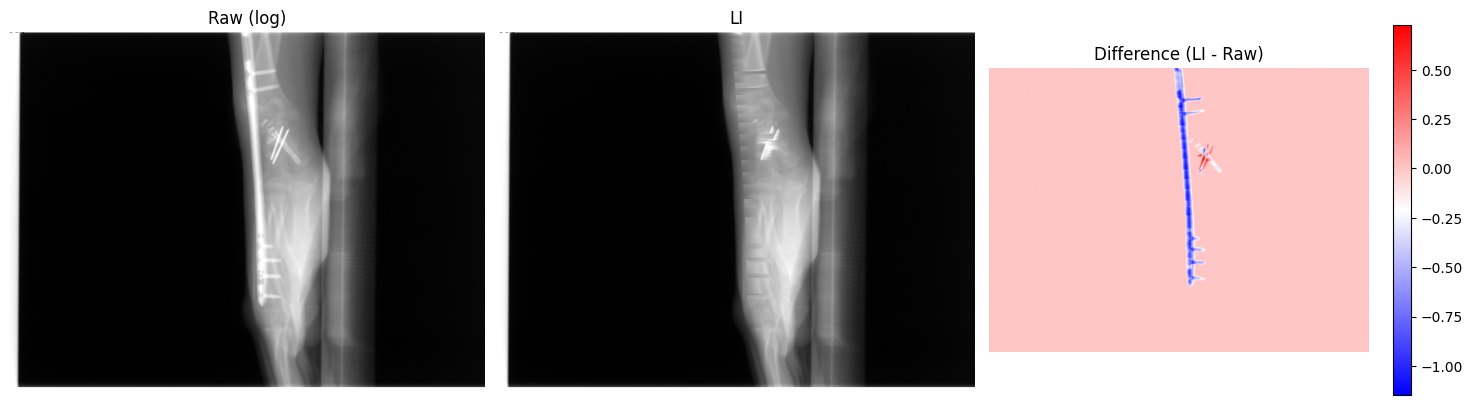

Saved: D:\NMAR\cbct_nmar_nb\proj_li_debug_view_240.png


In [59]:
   # # # 6) Linear interpolation MAR in projection space
proj_li = interp_proj_stack(proj_log, metal_trace_corr)
np.save(os.path.join(out_dir, "proj_li.npy"), proj_li)

# pick a representative projection
v = proj_log.shape[0] // 2

raw = proj_log[v]
li  = proj_li[v]
diff = li - raw

# normalize for display
def normalize(x):
    p1, p99 = np.percentile(x, (1, 99))
    return np.clip((x - p1) / (p99 - p1 + 1e-6), 0, 1)

raw_n = normalize(raw)
li_n  = normalize(li)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.title("Raw (log)")
plt.imshow(raw_n, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("LI")
plt.imshow(li_n, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Difference (LI - Raw)")
plt.imshow(diff, cmap='bwr')
plt.colorbar()
plt.axis('off')

plt.tight_layout()

# save
out_path = os.path.join(out_dir, f"proj_li_debug_view_{v}.png")
plt.savefig(out_path, dpi=150)
plt.show()

print(f"Saved: {out_path}")


Saved: D:\NMAR\cbct_nmar_nb\vol_li_LI.tif


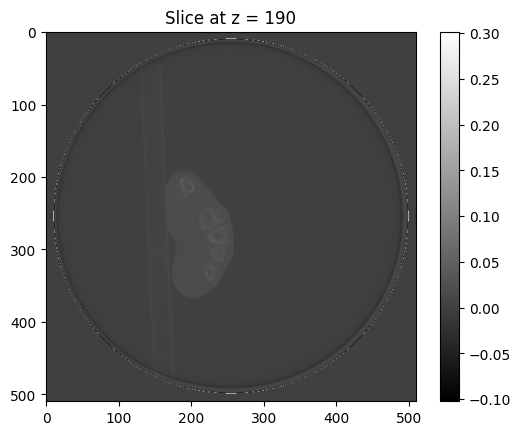

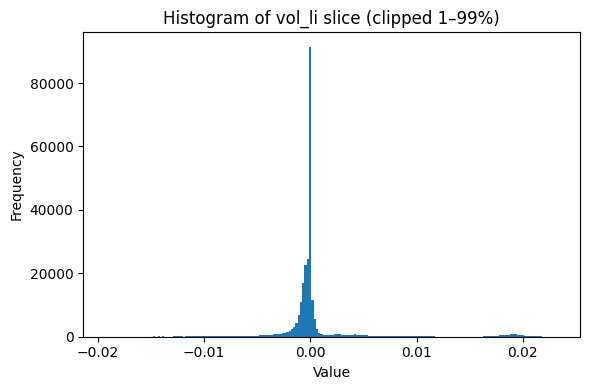

Saved: D:\NMAR\cbct_nmar_nb\vol_li_hist.png


In [60]:
  # #7) Reconstruct LI volume
vol_li = reconstruct_fdk(proj_li)
np.save(os.path.join(out_dir, "vol_li.npy"), vol_li)

z = vol_li.shape[0] // 2
slice_2d = vol_li[z]
out_path = os.path.join(out_dir, "vol_li_LI.tif")
tifffile.imwrite(out_path, slice_2d.astype(np.float32))
#
print(f"Saved: {out_path}")

plt.imshow(slice_2d, cmap='gray')
plt.colorbar()
plt.title(f"Slice at z = {z}")
plt.show()

vol_li = reconstruct_fdk(proj_li)
np.save(os.path.join(out_dir, "vol_li.npy"), vol_li)

z = vol_li.shape[0] // 2
# flatten + remove NaNs/Infs
vals = slice_2d[np.isfinite(slice_2d)].ravel()

# optional: clip extreme outliers for better visibility
p1, p99 = np.percentile(vals, (1, 99))
vals_clipped = vals[(vals >= p1) & (vals <= p99)]

plt.figure(figsize=(6,4))
plt.hist(vals_clipped, bins=200)
plt.title("Histogram of vol_li slice (clipped 1–99%)")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.tight_layout()

# save
hist_path = os.path.join(out_dir, "vol_li_hist.png")
plt.savefig(hist_path, dpi=150)
plt.show()

print(f"Saved: {hist_path}")

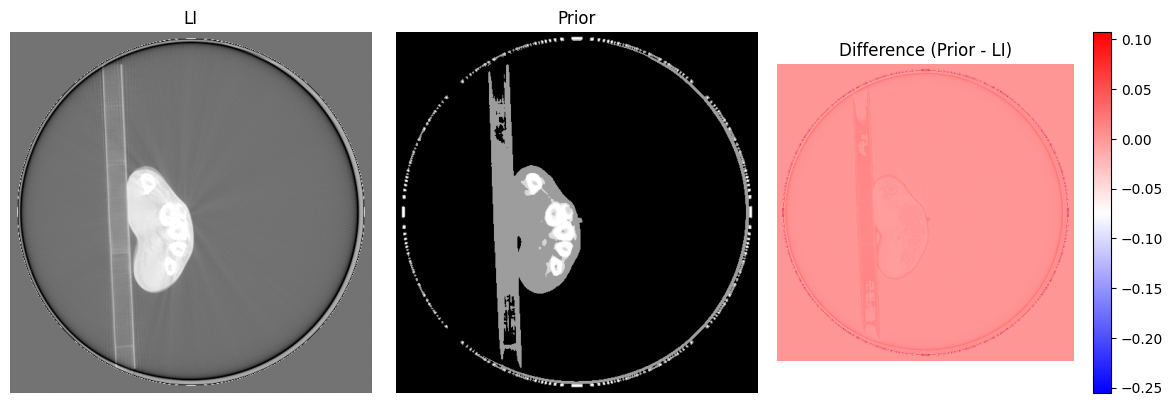

Saved: D:\NMAR\cbct_nmar_nb\prior_slice_debug.png
Saved: D:\NMAR\cbct_nmar_nb\vol_prior_mid_slice.tif


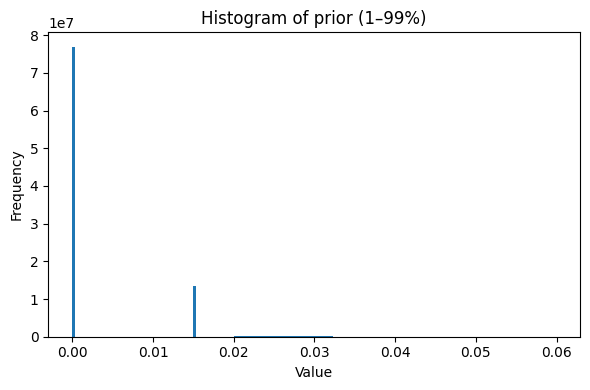

Saved: D:\NMAR\cbct_nmar_nb\prior_hist.png


In [61]:
# #8) Build prior volume
# #IMPORTANT:
# #If vol_li is already in attenuation units, use directly.
# #If it is HU-like, convert first:
# vol_li_mu = hu_to_mu(vol_li)
vol_li_mu = vol_li.copy()
#
prior_vol = build_prior_from_li(vol_li_mu, metal_vol)
np.save(os.path.join(out_dir, "prior_vol.npy"), prior_vol)
#

z = vol_li.shape[0] // 2

li_slice = vol_li[z]
prior_slice = prior_vol[z]

def normalize(x):
    p1, p99 = np.percentile(x, (1, 99))
    return np.clip((x - p1) / (p99 - p1 + 1e-6), 0, 1)

li_n = normalize(li_slice)
prior_n = normalize(prior_slice)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("LI")
plt.imshow(li_n, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Prior")
plt.imshow(prior_n, cmap='gray')
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Difference (Prior - LI)")
plt.imshow(prior_slice - li_slice, cmap='bwr')
plt.colorbar()
plt.axis('off')

plt.tight_layout()

out_path = os.path.join(out_dir, "prior_slice_debug.png")
plt.savefig(out_path, dpi=150)
plt.show()

print(f"Saved: {out_path}")

z = prior_vol.shape[0] // 2
slice_2d = prior_vol[z]
out_path = os.path.join(out_dir, "vol_prior_mid_slice.tif")
tifffile.imwrite(out_path, slice_2d.astype(np.float32))

print(f"Saved: {out_path}")
## histogram 

vals = prior_vol[np.isfinite(prior_vol)].ravel()

# clip for visibility
p1, p99 = np.percentile(vals, (1, 99))
vals_clip = vals[(vals >= p1) & (vals <= p99)]

plt.figure(figsize=(6,4))
plt.hist(vals_clip, bins=200)
plt.title("Histogram of prior (1–99%)")
plt.xlabel("Value")
plt.ylabel("Frequency")

plt.tight_layout()

hist_path = os.path.join(out_dir, "prior_hist.png")
plt.savefig(hist_path, dpi=150)
plt.show()

print(f"Saved: {hist_path}")

metal_vol.shape: (380, 510, 510)
prior_vol.shape: (380, 510, 510)
Input volume shape: (380, 510, 510)
LEAP volume shape: (380, 510, 510)


Text(0.5, 1.0, 'proj_prior')

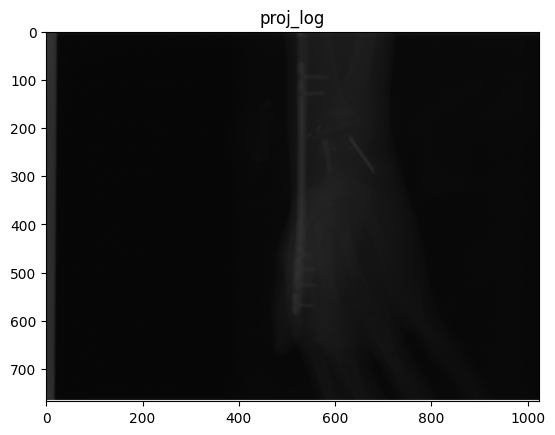

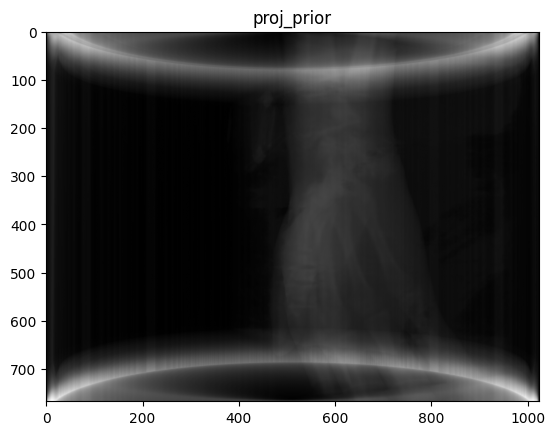

In [62]:
print("metal_vol.shape:", metal_vol.shape)
print("prior_vol.shape:", prior_vol.shape)

# f = leapct.allocate_volume()
# print("LEAP volume shape:", f.shape)

# # 9) Forward project prior
proj_prior = allocate_and_project(prior_vol)

# scale = np.median(proj_log) / np.median(proj_prior)
# prior_vol *= scale

# proj_prior = allocate_and_project(prior_vol)

np.save(os.path.join(out_dir, "proj_prior.npy"), proj_prior)

import matplotlib.pyplot as plt

plt.imshow(proj_log[180], cmap='gray')
plt.title("proj_log")

plt.figure()
plt.imshow(proj_prior[180], cmap='gray')
plt.title("proj_prior")

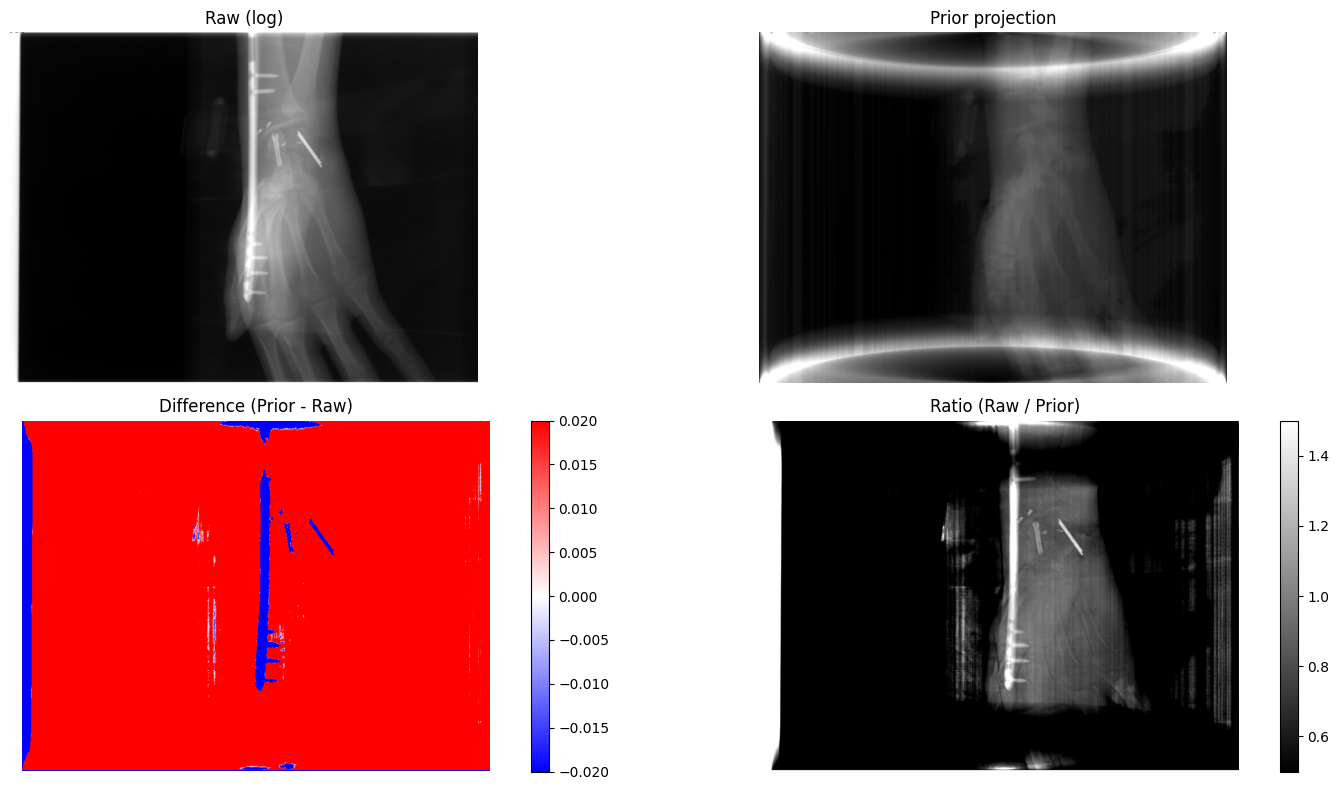

Saved: D:\NMAR\cbct_nmar_nb\proj_prior_debug_180.png


In [63]:
import matplotlib.pyplot as plt
import numpy as np
import os

v = 180  # same index you're using

raw = proj_log[v]
prior = proj_prior[v]

diff = prior - raw
ratio = raw / (prior + 1e-6)

def normalize(x):
    p1, p99 = np.percentile(x, (1, 99))
    return np.clip((x - p1) / (p99 - p1 + 1e-6), 0, 1)

raw_n = normalize(raw)
prior_n = normalize(prior)

plt.figure(figsize=(16, 8))

# Raw
plt.subplot(2, 2, 1)
plt.title("Raw (log)")
plt.imshow(raw_n, cmap='gray')
plt.axis('off')

# Prior
plt.subplot(2, 2, 2)
plt.title("Prior projection")
plt.imshow(prior_n, cmap='gray')
plt.axis('off')

# Difference
plt.subplot(2, 2, 3)
plt.title("Difference (Prior - Raw)")
plt.imshow(diff, cmap='bwr', vmin=-0.02, vmax=0.02)
plt.colorbar()
plt.axis('off')

# Ratio (THIS IS KEY FOR NMAR)
plt.subplot(2, 2, 4)
plt.title("Ratio (Raw / Prior)")
plt.imshow(ratio, cmap='gray', vmin=0.5, vmax=1.5)
plt.colorbar()
plt.axis('off')

plt.tight_layout()

out_path = os.path.join(out_dir, f"proj_prior_debug_{v}.png")
plt.savefig(out_path, dpi=150)
plt.show()

print(f"Saved: {out_path}")










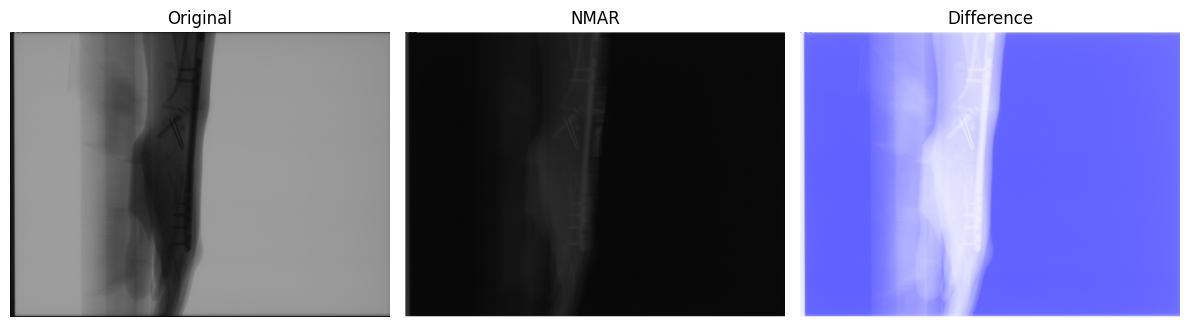

Saved: D:\NMAR\cbct_nmar_nb\diff_0000.png


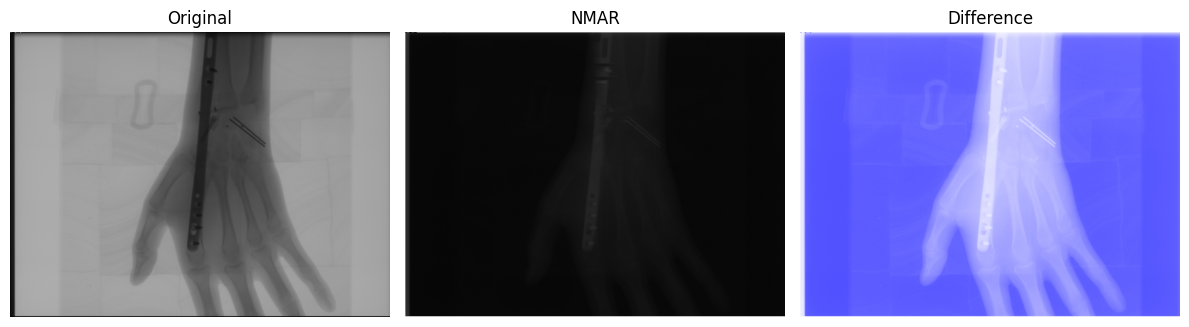

Saved: D:\NMAR\cbct_nmar_nb\diff_0120.png


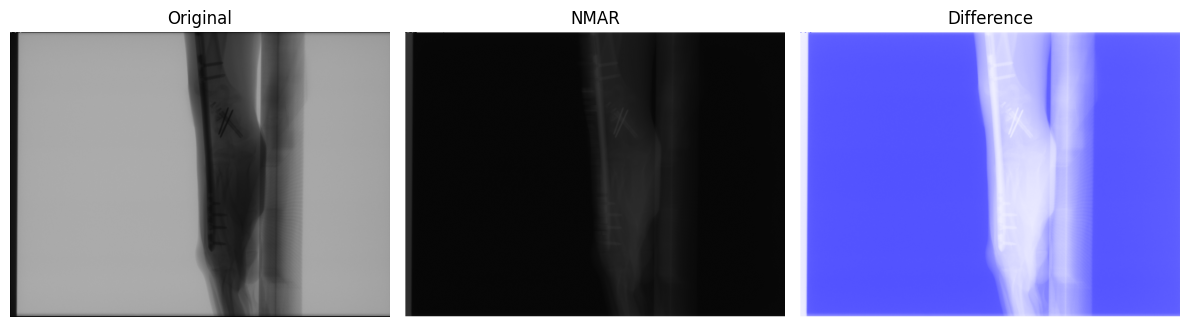

Saved: D:\NMAR\cbct_nmar_nb\diff_0240.png


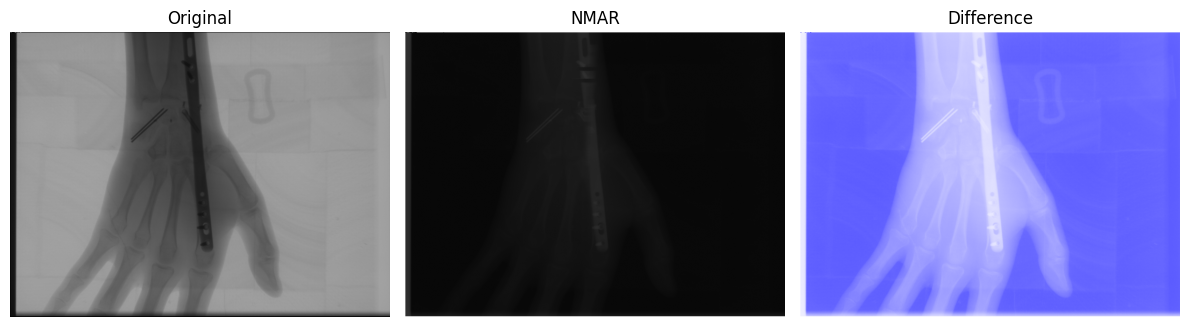

Saved: D:\NMAR\cbct_nmar_nb\diff_0360.png


In [64]:
def run_nmar(raw_proj, proj_prior, metal_trace, eps=1e-6):
    proj_prior = np.clip(proj_prior, eps, None)

    proj_norm = raw_proj / proj_prior
    proj_norm_interp = interp_proj_stack(proj_norm, metal_trace)

    proj_nmar = proj_norm_interp * proj_prior
    proj_nmar[~metal_trace] = raw_proj[~metal_trace]

    return proj_nmar

# # 10) NMAR
proj_nmar = run_nmar(proj_log, proj_prior, metal_trace)
np.save(os.path.join(out_dir, "proj_nmar.npy"), proj_nmar)
#
# print("Saved NMAR projection stack.")

import matplotlib.pyplot as plt
import numpy as np

for v in [0, 120, 240, 360]:
    diff = proj_nmar[v] - raw_proj[v]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(raw_proj[v], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(proj_nmar[v], cmap='gray')
    plt.title("NMAR")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(diff, cmap='bwr',
               vmin=-np.max(np.abs(diff)),
               vmax=np.max(np.abs(diff)))
    plt.title("Difference")
    plt.axis('off')

    plt.tight_layout()

    save_path = os.path.join(out_dir, f"diff_{v:04d}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Saved: {save_path}")
#

Scale factor: 1.0


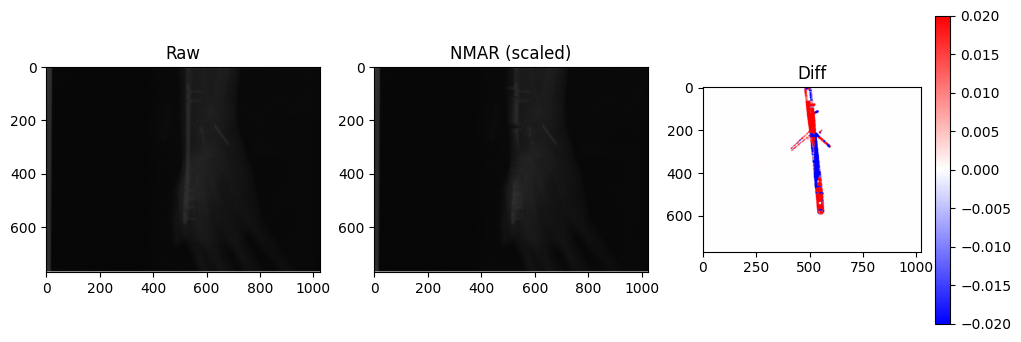

In [65]:
# mask = where metal is NOT present
nonmetal_mask = ~metal_trace_corr

raw_vals = proj_log[nonmetal_mask]
nmar_vals = proj_nmar[nonmetal_mask]

# avoid zeros
valid = (nmar_vals > 1e-6)

raw_vals = raw_vals[valid]
nmar_vals = nmar_vals[valid]

# compute scale
scale = np.median(raw_vals / nmar_vals)

# apply
proj_nmar_scaled = proj_nmar * scale

print("Scale factor:", scale)

v = 180

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Raw")
plt.imshow(proj_log[v], cmap='gray')

plt.subplot(1,3,2)
plt.title("NMAR (scaled)")
plt.imshow(proj_nmar_scaled[v], cmap='gray')

plt.subplot(1,3,3)
plt.title("Diff")
plt.imshow(proj_nmar_scaled[v] - proj_log[v], cmap='bwr', vmin=-0.02, vmax=0.02)
plt.colorbar()

plt.show()

In [47]:
vol_nmar = reconstruct_fdk(proj_nmar)
np.save(os.path.join(out_dir, "vol_nmar.npy"), vol_nmar)

z = vol_nmar.shape[0] // 2
slice_2d = vol_nmar[z]
out_path = os.path.join(out_dir, "vol_nmar_mid_slice.tif")
tifffile.imwrite(out_path, slice_2d.astype(np.float32))

print(f"Saved: {out_path}")

# -----------------------------
# Difference: NMAR vs uncorrected
# -----------------------------
diff_vol = vol_nmar - vol_test
np.save(os.path.join(out_dir, "vol_diff_nmar_vs_raw.npy"), diff_vol)

# pick same slice index
z = vol_nmar.shape[0] // 2

slice_raw = vol_test[z]
slice_nmar = vol_nmar[z]
slice_diff = diff_vol[z]


# -----------------------------
# Normalize for visualization
# -----------------------------
def normalize(img):
    p1, p99 = np.percentile(img, (1, 99))
    return np.clip((img - p1) / (p99 - p1 + 1e-6), 0, 1)


raw_norm = normalize(slice_raw)
nmar_norm = normalize(slice_nmar)

# symmetric scaling for difference
vmax = np.percentile(np.abs(slice_diff), 99)
diff_vis = np.clip(slice_diff / (vmax + 1e-6), -1, 1)

# -----------------------------
# Save outputs
# -----------------------------
tifffile.imwrite(os.path.join(out_dir, "slice_raw.tif"), (raw_norm * 255).astype(np.uint8))
tifffile.imwrite(os.path.join(out_dir, "slice_nmar.tif"), (nmar_norm * 255).astype(np.uint8))

# difference as float (for analysis)
tifffile.imwrite(
    os.path.join(out_dir, "slice_diff_float.tif"),
    slice_diff.astype(np.float32)
)

# difference as visualization (shift to 0–255)
diff_uint8 = ((diff_vis + 1) / 2 * 255).astype(np.uint8)
tifffile.imwrite(
    os.path.join(out_dir, "slice_diff_vis.tif"),
    diff_uint8
)

print("Saved raw, NMAR, and difference slices.")

Saved: D:\NMAR\cbct_nmar_nb\vol_nmar_mid_slice.tif
Saved raw, NMAR, and difference slices.
